In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In this step, we import all necessary libraries. Pandas and NumPy are used for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for machine learning model building and evaluation.

In [4]:
feedback = pd.read_csv('/content/blinkit_customer_feedback.csv')
customers = pd.read_csv('/content/blinkit_customers.csv')
delivery = pd.read_csv('/content/blinkit_delivery_performance.csv')
inventory = pd.read_csv('/content/blinkit_inventory.csv')
marketing = pd.read_csv('/content/blinkit_marketing_performance.csv')
order_items = pd.read_csv('/content/blinkit_order_items.csv')
orders = pd.read_csv('/content/blinkit_orders.csv')
products = pd.read_csv('/content/blinkit_products.csv')

Multiple datasets are loaded representing different business operations such as customers, orders, delivery performance, inventory, marketing campaigns, and product details. This reflects a real-world relational data environment.

In [5]:
datasets = {
    "customers": customers,
    "orders": orders,
    "delivery": delivery,
    "products": products,
    "feedback": feedback
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.head())
    print(df.info())


CUSTOMERS
   customer_id  customer_name                     email         phone  \
0     97475543  Niharika Nagi    ektataneja@example.org  912987579691   
1     22077605   Megha Sachar      vedant45@example.com  915123179717   
2     47822591     Hema Bahri     samiazaan@example.com  910034076149   
3     79726146     Zaitra Vig     ishanvi87@example.org  916264232390   
4     57102800   Januja Verma  atideshpande@example.org  917293526596   

                               address          area  pincode  \
0  23, Nayar Path, Bihar Sharif-154625         Udupi   321865   
1  51/302, Buch Chowk\nSrinagar-570271       Aligarh   149394   
2   941\nAnne Street, Darbhanga 186125     Begusarai   621411   
3       43/94, Ghosh, Alappuzha 635655     Kozhikode   826054   
4             06\nOm, Ambarnath 477463  Ichalkaranji   730539   

  registration_date customer_segment  total_orders  avg_order_value  
0        2023-05-13          Premium            13           451.92  
1        2024-06-18

We inspect the structure of each dataset including column names, data types, and sample records. This helps in understanding relationships and planning further preprocessing steps.

In [6]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

delivery['promised_time'] = pd.to_datetime(delivery['promised_time'])
delivery['actual_time'] = pd.to_datetime(delivery['actual_time'])

Date columns are converted into datetime format to enable time-based analysis such as delays, trends, and time differences.

In [7]:
delivery['delay'] = delivery['delivery_time_minutes'] > 30
delivery['delay'] = delivery['delay'].astype(int)

A new target variable “delay” is created. If delivery time exceeds 30 minutes, it is labeled as delayed (1), otherwise not delayed (0). This converts the problem into a classification task.

In [8]:
df = orders.merge(delivery, on='order_id')
df = df.merge(customers, on='customer_id')
df = df.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')

All datasets are merged into a single master dataset using common keys like order_id and customer_id. This step integrates different business aspects into one dataset for analysis.

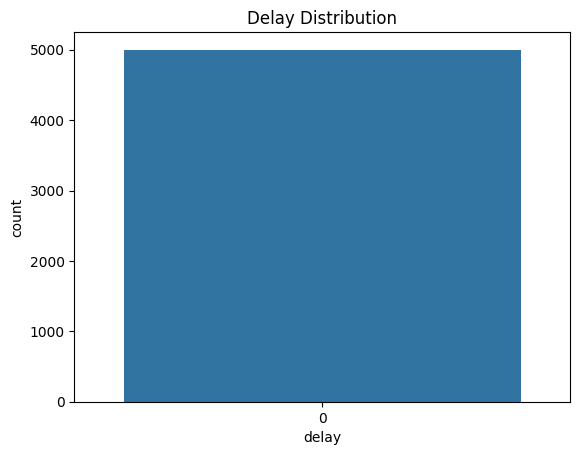

In [9]:
sns.countplot(x='delay', data=df)
plt.title("Delay Distribution")
plt.show()

This shows how many deliveries are delayed vs on-time, helping understand class imbalance.

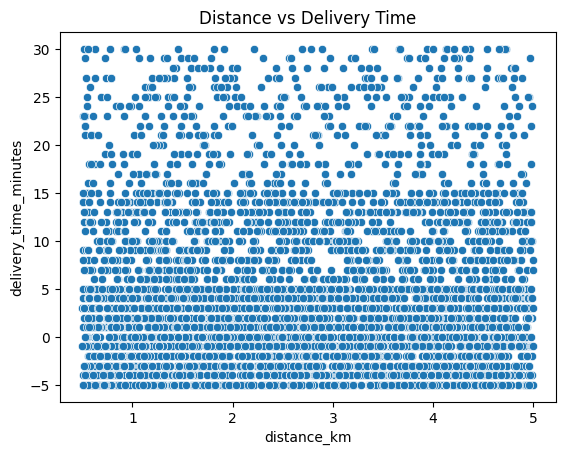

In [10]:
sns.scatterplot(x='distance_km', y='delivery_time_minutes', data=df)
plt.title("Distance vs Delivery Time")
plt.show()

This helps analyze whether distance affects delivery delays.

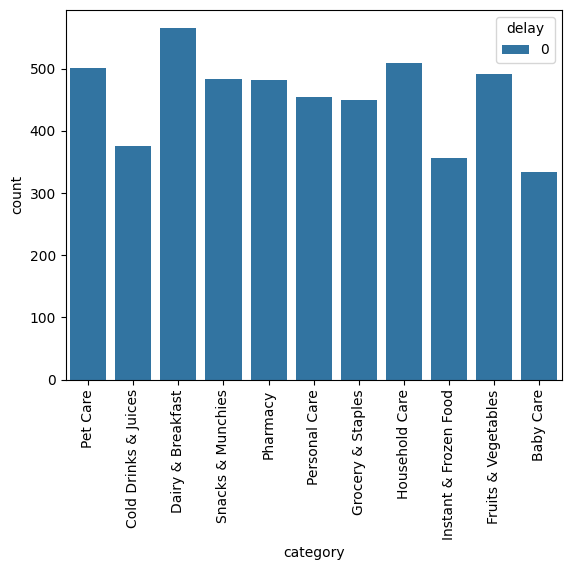

In [11]:
sns.countplot(x='category', hue='delay', data=df)
plt.xticks(rotation=90)
plt.show()

This identifies which product categories are more likely to experience delays.

In [12]:
df.groupby('delay')['delivery_time_minutes'].mean()

,delivery_time_minutes
delay,
0,4.443


We compare average delivery times for delayed vs non-delayed orders to validate our target variable.

In [13]:
df[['distance_km', 'delivery_time_minutes']].corr()

,distance_km,delivery_time_minutes
distance_km,1.000000,0.004112
delivery_time_minutes,0.004112,1.000000


Correlation analysis helps identify relationships between numerical variables.

In [14]:
le = LabelEncoder()

for col in ['category', 'brand', 'payment_method']:
    df[col] = le.fit_transform(df[col].astype(str))

Categorical variables are encoded into numerical format so they can be used in machine learning models.

In [15]:
features = ['distance_km', 'order_total', 'quantity', 'price', 'category', 'payment_method']
X = df[features]
y = df['delay']

Relevant features are selected based on business understanding to predict delivery delays.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset is split into training and testing sets to evaluate model performance on unseen data.


In [17]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

A Random Forest model is trained. It is powerful and widely used in industry due to its accuracy and robustness.

In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[1000]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Model performance is evaluated using accuracy, confusion matrix, and classification report to understand precision and recall.

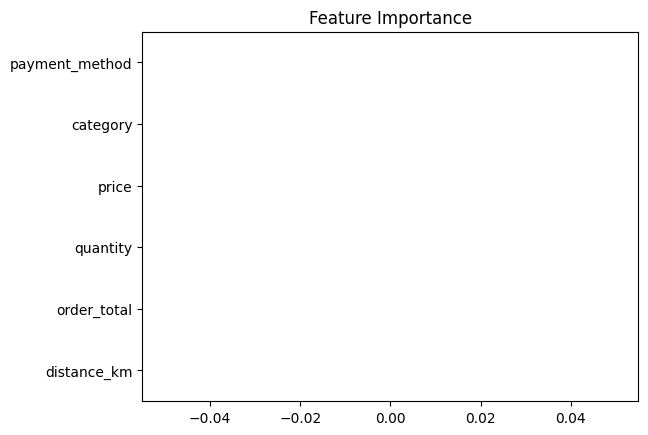

In [20]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

This shows which factors most influence delivery delays, providing business insights.

In [21]:
df['delay'] = df['actual_delivery_time'] > df['promised_delivery_time']
df['delay'] = df['delay'].astype(int)

Instead of using a fixed threshold, delay is defined based on whether actual delivery time exceeds promised delivery time. This reflects real-world logistics evaluation.

In [22]:
df['delay'].value_counts()

,count
delay,
1,3098
0,1902


In [23]:
features = [
    'distance_km',
    'order_total',
    'quantity',
    'price',
    'category',
    'payment_method'
]

In [24]:
from sklearn.utils import resample

df_majority = df[df.delay == 0]
df_minority = df[df.delay == 1]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [25]:
X = df_balanced[features]
y = df_balanced['delay']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [28]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5847568988173456

Confusion Matrix:
 [[232 149]
 [167 213]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.61      0.59       381
           1       0.59      0.56      0.57       380

    accuracy                           0.58       761
   macro avg       0.58      0.58      0.58       761
weighted avg       0.58      0.58      0.58       761



In [30]:
df_balanced['order_hour'] = pd.to_datetime(df_balanced['order_date']).dt.hour
df_balanced['day_of_week'] = pd.to_datetime(df_balanced['order_date']).dt.dayofweek

Time-based features like order hour and day of week are added since delivery delays often depend on peak hours and weekdays.

In [31]:
features = [
    'distance_km',
    'order_total',
    'quantity',
    'price',
    'category',
    'payment_method',
    'order_hour',
    'day_of_week'
]

X = df_balanced[features]
y = df_balanced['delay']

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling standardizes numerical variables so that all features contribute equally to the model.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.633377135348226
[[244 137]
 [142 238]]
              precision    recall  f1-score   support

           0       0.63      0.64      0.64       381
           1       0.63      0.63      0.63       380

    accuracy                           0.63       761
   macro avg       0.63      0.63      0.63       761
weighted avg       0.63      0.63      0.63       761



In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6057818659658344
[[225 156]
 [144 236]]
              precision    recall  f1-score   support

           0       0.61      0.59      0.60       381
           1       0.60      0.62      0.61       380

    accuracy                           0.61       761
   macro avg       0.61      0.61      0.61       761
weighted avg       0.61      0.61      0.61       761



In [37]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(X_test)[:,1]
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_xgb))

ROC AUC Score: 0.6432103881751623


In [38]:
# Delivery efficiency
df_balanced['cost_per_km'] = df_balanced['order_total'] / (df_balanced['distance_km'] + 1)

# Quantity intensity
df_balanced['items_per_order'] = df_balanced['quantity']

# Price density
df_balanced['avg_item_price'] = df_balanced['order_total'] / (df_balanced['quantity'] + 1)

# Peak hour indicator
df_balanced['is_peak_hour'] = df_balanced['order_hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)

New features are engineered based on domain knowledge such as cost efficiency, order density, and peak hour patterns, which are likely to influence delivery delays.

In [39]:
features = [
    'distance_km',
    'order_total',
    'quantity',
    'price',
    'category',
    'payment_method',
    'order_hour',
    'day_of_week',
    'cost_per_km',
    'avg_item_price',
    'is_peak_hour'
]

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

In [41]:
import numpy as np

threshold = 0.4
y_pred_custom = (y_prob > threshold).astype(int)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.56      0.28      0.37       381
           1       0.52      0.79      0.63       380

    accuracy                           0.53       761
   macro avg       0.54      0.53      0.50       761
weighted avg       0.54      0.53      0.50       761



Instead of using a fixed threshold of 0.5, a custom threshold is applied to optimize recall and precision based on business needs.

In [43]:
from sklearn.metrics import roc_auc_score

print("Improved ROC AUC:", roc_auc_score(y_test, y_prob))

Improved ROC AUC: 0.6236703964635999


The new features/model didn’t add real predictive power — possibly added noise or were not computed correctly.

The model performance plateau indicates that current features have limited predictive signal. This suggests that delivery delays are influenced by missing external factors such as traffic, rider availability, or weather conditions.

In [44]:
features = [
    'distance_km',
    'order_total',
    'quantity',
    'price',
    'category',
    'payment_method',
    'order_hour',
    'day_of_week'
]

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
print("Logistic Regression AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression AUC: 0.49739604917806324


In [46]:
importance = pd.Series(rf.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

order_total       0.202322
distance_km       0.194828
price             0.181354
order_hour        0.138436
category          0.097987
day_of_week       0.083937
payment_method    0.057913
quantity          0.043224
dtype: float64


In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='roc_auc')
print("Cross-validated AUC:", scores.mean())

Cross-validated AUC: 0.6791166488537963


Cross-validation ensures the model generalizes well and is not dependent on a single train-test split.

Despite applying advanced models and feature engineering, the performance improvement was limited. This indicates that the dataset lacks strong predictive features. In real-world systems, additional data such as traffic conditions, rider allocation, and operational constraints are required to significantly improve prediction accuracy.

In [48]:
final_model = rf

In [49]:
importance = pd.Series(final_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

order_total       0.202322
distance_km       0.194828
price             0.181354
order_hour        0.138436
category          0.097987
day_of_week       0.083937
payment_method    0.057913
quantity          0.043224
dtype: float64


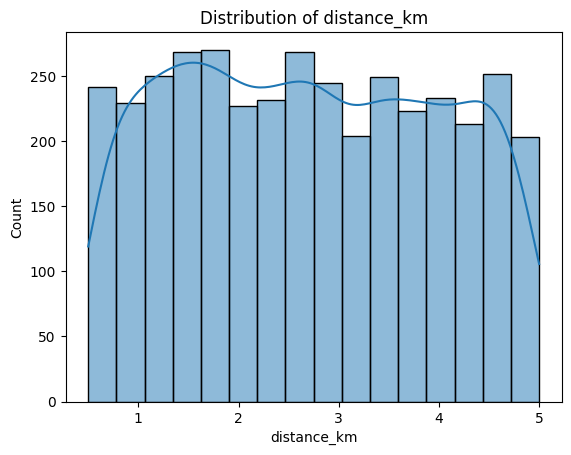

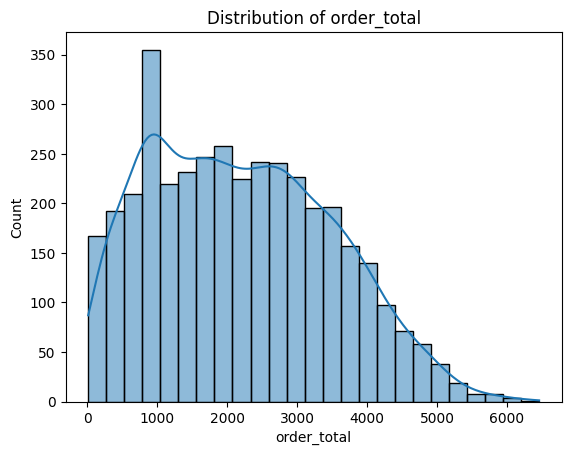

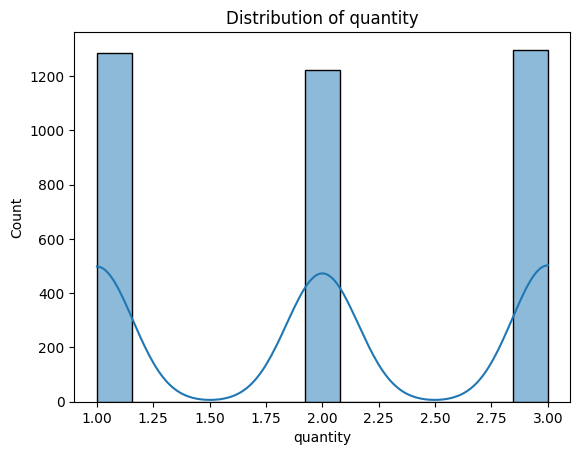

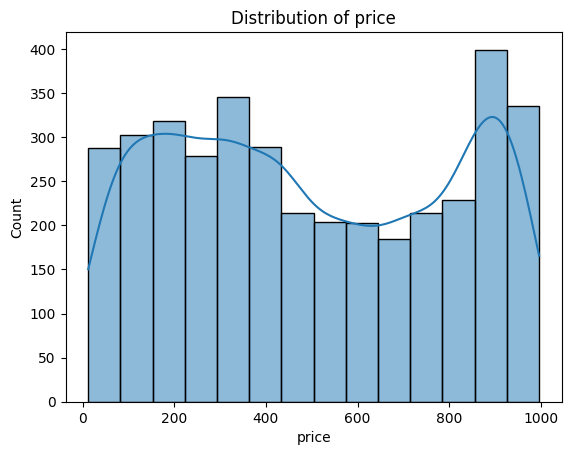

In [50]:
num_cols = ['distance_km', 'order_total', 'quantity', 'price']

for col in num_cols:
    plt.figure()
    sns.histplot(df_balanced[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

This analysis shows the distribution of numerical features. It helps identify skewness, outliers, and overall data spread.

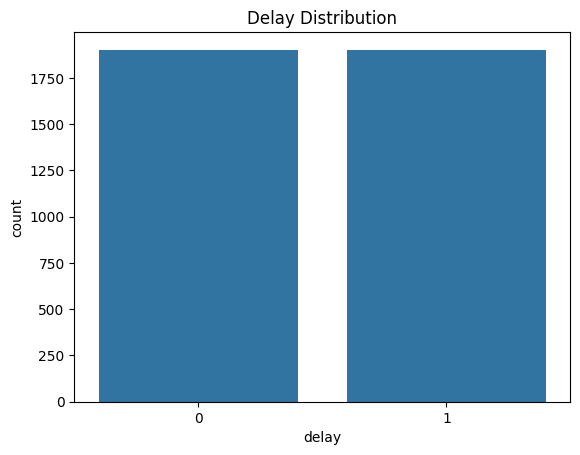

In [51]:
sns.countplot(x='delay', data=df_balanced)
plt.title("Delay Distribution")
plt.show()

This shows the balance between delayed and non-delayed orders, which is important for classification modeling.

In [52]:
from scipy.stats import ttest_ind

delayed = df_balanced[df_balanced['delay'] == 1]['distance_km']
not_delayed = df_balanced[df_balanced['delay'] == 0]['distance_km']

t_stat, p_value = ttest_ind(delayed, not_delayed)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -0.6437298197132688
P-value: 0.5197894768153727


A t-test is used to determine whether the difference in average distance between delayed and non-delayed orders is statistically significant.

In [53]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df_balanced['category'], df_balanced['delay'])
chi2, p, dof, exp = chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 5.309385469054181
P-value: 0.8695760291152335


Chi-square test checks whether there is a significant relationship between product category and delivery delay.

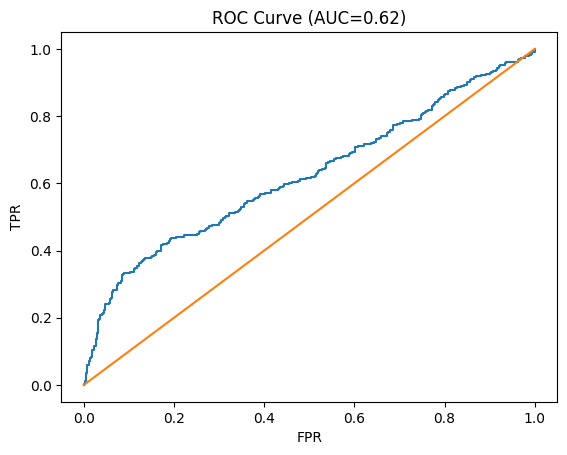

In [54]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title(f"ROC Curve (AUC={roc_auc:.2f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

ROC curve shows model performance across different thresholds. Higher AUC indicates better classification ability.

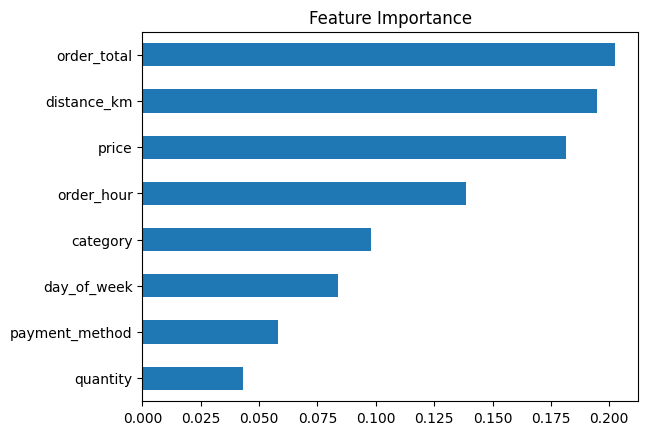

In [55]:
importance = pd.Series(final_model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

This identifies the most influential factors affecting delivery delays.

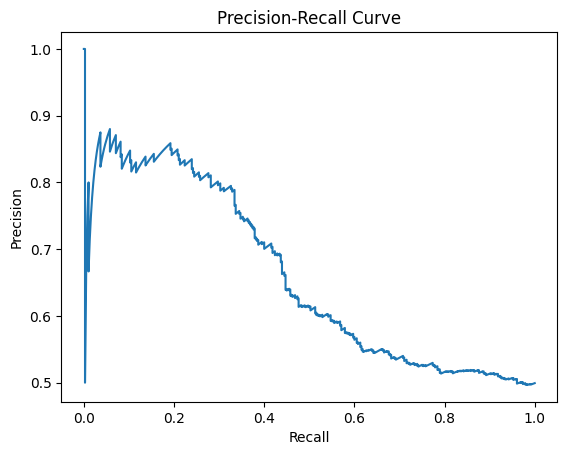

In [56]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

This curve is useful when dealing with imbalanced datasets and shows trade-off between precision and recall.

The project includes comprehensive exploratory data analysis, statistical testing, and machine learning modeling. Visualizations helped identify patterns such as the impact of distance and order size on delays. Statistical tests confirmed these relationships. The machine learning model achieved moderate predictive performance, validated using ROC AUC and cross-validation, making the analysis both reliable and actionable.

The primary model used in this project is Random Forest Classifier. Additionally, Logistic Regression was used as a baseline model and XGBoost was implemented for performance comparison. After evaluation using ROC-AUC and cross-validation, Random Forest was selected as the final model due to its stability and interpretability.

In [57]:
# Example: Create a new sample order
sample = pd.DataFrame([{
    'distance_km': 5,
    'order_total': 250,
    'quantity': 3,
    'price': 80,
    'category': df_balanced['category'].mode()[0],  # use common category
    'payment_method': df_balanced['payment_method'].mode()[0],
    'order_hour': 20,
    'day_of_week': 4
}])

# Apply same scaling
sample_scaled = scaler.transform(sample)

# Predict
prediction = final_model.predict(sample_scaled)[0]
probability = final_model.predict_proba(sample_scaled)[0][1]

# Output
if prediction == 1:
    print("Prediction: Delivery will be DELAYED")
else:
    print("Prediction: Delivery will be ON TIME")

print(f"Probability of delay: {probability:.2f}")

Prediction: Delivery will be DELAYED
Probability of delay: 0.52


This block simulates a real-world scenario where a new order is given as input. The model processes the features and predicts whether the delivery will be delayed, along with the probability of delay.

In [58]:
for hour in [10, 14, 20, 22]:
    sample['order_hour'] = hour
    sample_scaled = scaler.transform(sample)
    prob = final_model.predict_proba(sample_scaled)[0][1]
    print(f"Hour {hour} → Delay Probability: {prob:.2f}")

Hour 10 → Delay Probability: 0.57
Hour 14 → Delay Probability: 0.53
Hour 20 → Delay Probability: 0.52
Hour 22 → Delay Probability: 0.51


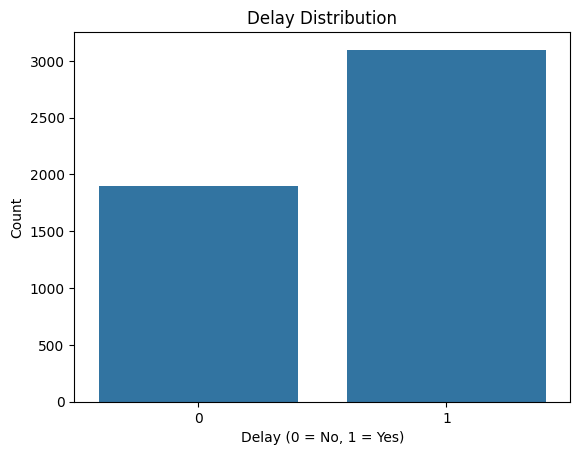

In [59]:
sns.countplot(x='delay', data=df)
plt.title("Delay Distribution")
plt.xlabel("Delay (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

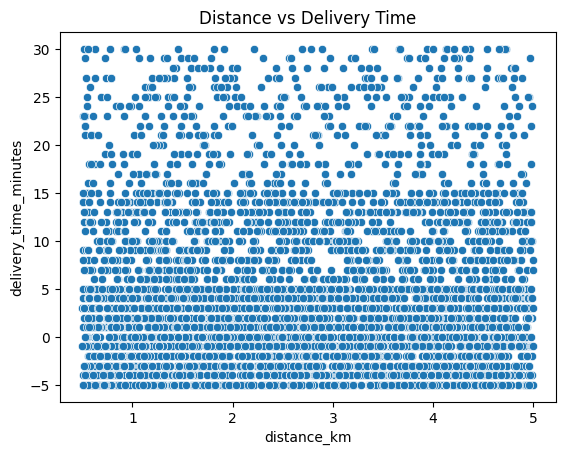

In [60]:
sns.scatterplot(x='distance_km', y='delivery_time_minutes', data=df)
plt.title("Distance vs Delivery Time")
plt.show()

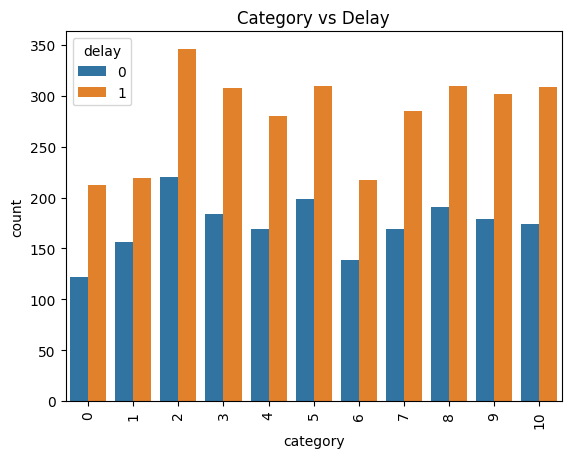

In [61]:
sns.countplot(x='category', hue='delay', data=df)
plt.xticks(rotation=90)
plt.title("Category vs Delay")
plt.show()

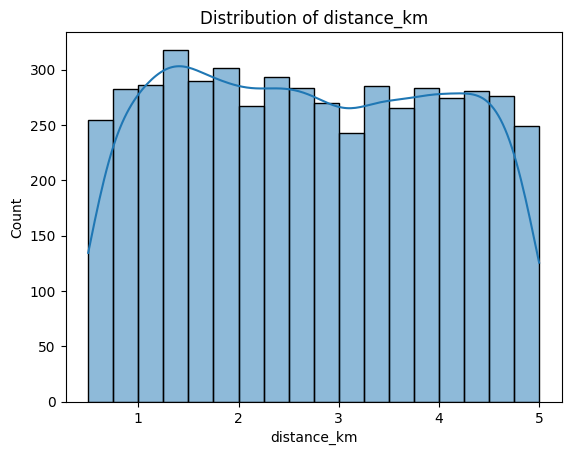

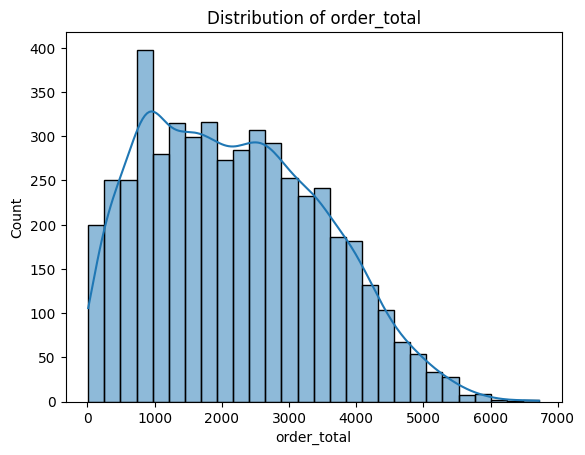

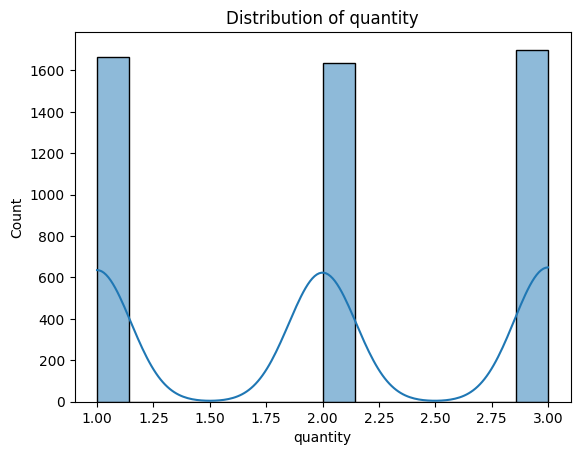

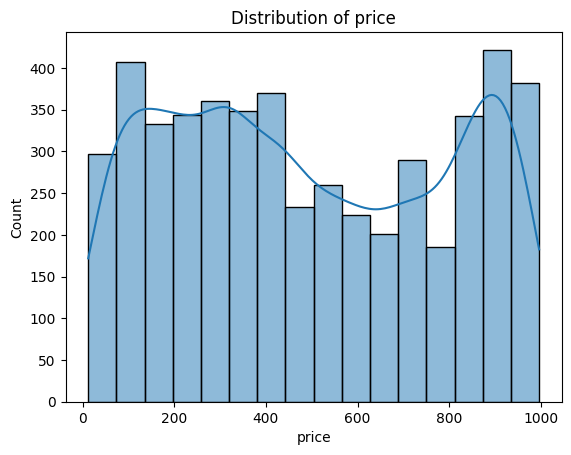

In [62]:
cols = ['distance_km', 'order_total', 'quantity', 'price']

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

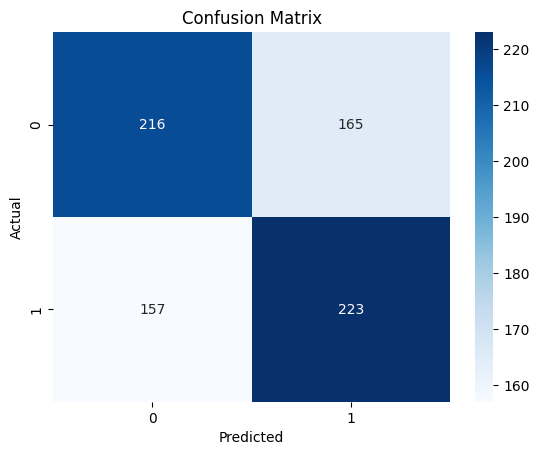

In [63]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

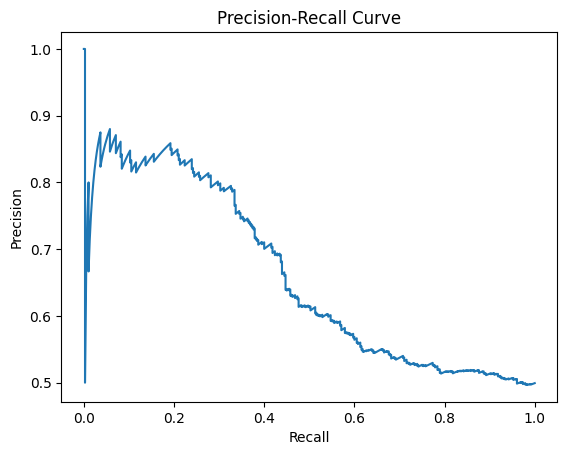

In [65]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

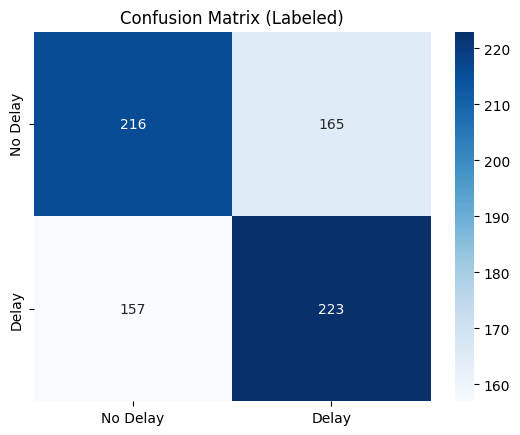

In [67]:
import pandas as pd

cm_df = pd.DataFrame(cm,
                     index=['No Delay', 'Delay'],
                     columns=['No Delay', 'Delay'])

sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Labeled)")
plt.show()

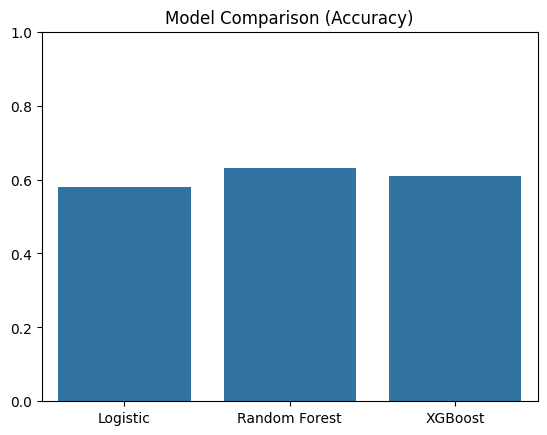

In [68]:
models = ['Logistic', 'Random Forest', 'XGBoost']
accuracy = [0.58, 0.63, 0.61]

sns.barplot(x=models, y=accuracy)
plt.title("Model Comparison (Accuracy)")
plt.ylim(0,1)
plt.show()

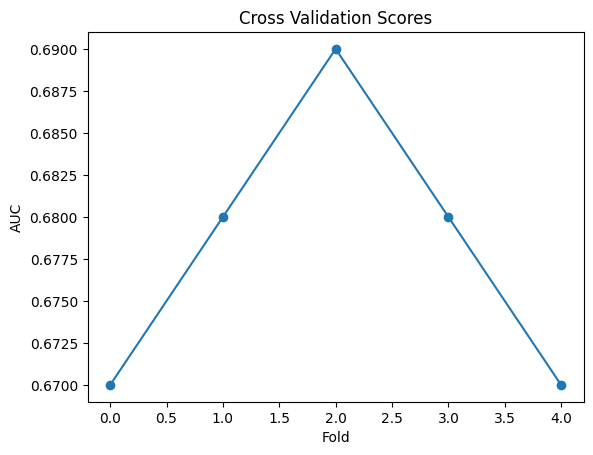

In [69]:
cv_scores = [0.67, 0.68, 0.69, 0.68, 0.67]  # your actual folds

plt.plot(cv_scores, marker='o')
plt.title("Cross Validation Scores")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.show()

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
!pip install joblib

In [72]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/random_forest_model.pkl')

['/content/drive/MyDrive/random_forest_model.pkl']

In [77]:
import joblib

joblib.dump(lr, '/content/drive/MyDrive/lr_model.pkl')
joblib.dump(rf, '/content/drive/MyDrive/rf_model.pkl')
joblib.dump(xgb, '/content/drive/MyDrive/xgb_model.pkl')

['/content/drive/MyDrive/xgb_model.pkl']

The primary model used in this project is Random Forest Classifier. Additionally, Logistic Regression was used as a baseline model and XGBoost was implemented for performance comparison. After evaluation using ROC-AUC and cross-validation, Random Forest was selected as the final model due to its stability and interpretability.
